# Chapter 15: The Trifocal Tensor

Source orientation: printed pages 365-390; PDF pages 383-408.

This notebook is an original computational treatment of the chapter. The source pages were used to identify the sequence of ideas: line-triplet incidence, the three tensor slices, plane-induced homographies, trilinear point and line relations, point and line transfer, epipoles, and the compatibility of the three pairwise fundamental matrices.

## Chapter Goal

By the end of this chapter notebook, a reader should be able to build a trifocal tensor from three canonical cameras, inspect its three matrix slices, use it for line and point transfer, recover the two fundamental matrices involving the first view, and explain why point transfer by the tensor avoids the trifocal-plane failure mode of pairwise epipolar transfer.

## Computational Translation Guide

- A three-view camera system is represented in the canonical projective frame
  \[P=[I\mid 0],\quad P'=[A\mid a_4],\quad P''=[B\mid b_4].\]
  This frame loses no projective image geometry because a 3D projective change of coordinates can put the first camera in this form.
- The trifocal tensor is stored as three `3 x 3` slices `T[0]`, `T[1]`, and `T[2]`, where
  \[T_i=a_i b_4^T-a_4 b_i^T.\]
  The slice index belongs to the first view; the rows and columns belong to the second and third views.
- A line triple is checked by `l1[i] = l2.T @ T[i] @ l3`, up to homogeneous scale.
- A line in the second view contracts the tensor to a homography from view 1 to view 3:
  \[H_{13}(l')=[T_1^T l',T_2^T l',T_3^T l'] .\]
- A point triple is checked by the trilinear matrix
  \[[x']_x \left(\sum_i x_i T_i\right)[x'']_x.\]
  Exact correspondences make this matrix zero up to floating-point roundoff.
- Epipoles are read from the common intersections of the left and right null-lines of the tensor slices, then used to recover `F21` and `F31`.

## Library Routing

| Chapter concept | Representation | Library route | Inspection target | Validation |
| --- | --- | --- | --- | --- |
| Back-projected image lines meet in one 3D line | 3D planes through camera centers and a shared space line | `matplotlib` 3D with transparent plane patches | The three planes share the same spatial line | Scale-invariant line-transfer residual |
| Tensor slices and epipoles | Heatmaps plus null-lines in views 2 and 3 | `numpy` SVD plus `matplotlib` | Each rank-2 slice contributes a null-line; those lines meet at the epipole | Slice ranks, determinants, null-line incidences |
| Plane-induced point transfer | Interactive 3D plane and image transfer panel | `plotly` HTML | A line in view 2 selects a plane and therefore a homography from view 1 to view 3 | Homography transfer error for points on the plane |
| Epipolar transfer failure near the trifocal plane | Error-vs-offset curve under identical small image perturbations | `numpy` and `matplotlib` | Pairwise epipolar-line intersection becomes ill-conditioned near the trifocal plane | Error curve and epipolar-line angle |
| Trilinearities | Exact and perturbed residual heatmaps | `numpy`, `matplotlib`, and a small `sympy` rank scaffold | The exact point triple makes all nine entries vanish; perturbing one view breaks them | Max exact residual, perturbed residual, symbolic `det(u v^T-p q^T)=0` |
| Pairwise fundamental consistency | Epipole panels plus compatibility bars | `numpy` and `matplotlib` | The three pairwise matrices have distinct epipoles but satisfy the compatibility scalars | Compatibility values and epipolar residuals |

OpenCV is intentionally not used in this chapter pass: Chapter 15 is about exact projective relations once the cameras or tensor are known. Estimation from image measurements is deferred to Chapter 16, where OpenCV-style fitting is the natural route.

In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-15"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
for child in ["figures", "interactive", "checks", "tables"]:
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)

ARTIFACT_ROOT.relative_to(BOOK_ROOT)

WindowsPath('artifacts/chapter-15')

In [2]:
import math

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp

from utils.artifacts import assert_artifacts, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html
from utils.cameras import camera_center, skew
from utils.epipolar import fundamental_from_cameras, sampson_errors
from utils.projective import dehomogenize, homogenize, line_through

np.set_printoptions(precision=5, suppress=True)

artifact_paths = []
check_values = {}

COLORS = {
    "blue": "#2563eb",
    "orange": "#f97316",
    "green": "#16a34a",
    "purple": "#7c3aed",
    "red": "#dc2626",
    "gray": "#475569",
}


def normalize_point(x, eps=1e-12):
    arr = np.asarray(x, dtype=float)
    if arr.ndim == 1:
        if abs(arr[-1]) > eps:
            return arr / arr[-1]
        norm = np.linalg.norm(arr)
        return arr / norm if norm > eps else arr
    return np.asarray([normalize_point(row, eps=eps) for row in arr])


def normalize_vector(v, eps=1e-12):
    arr = np.asarray(v, dtype=float)
    norm = np.linalg.norm(arr)
    return arr / norm if norm > eps else arr


def project(P, points3d):
    hp = homogenize(points3d) if np.asarray(points3d).shape[-1] == 3 else np.asarray(points3d, dtype=float)
    return normalize_point((P @ hp.T).T)


def left_null_vector(M):
    return normalize_vector(np.linalg.svd(np.asarray(M, dtype=float).T)[2][-1])


def right_null_vector(M):
    return normalize_vector(np.linalg.svd(np.asarray(M, dtype=float))[2][-1])


def matrix_rank_residual(M):
    s = np.linalg.svd(M, compute_uv=False)
    return float(s[-1] / max(s[0], 1e-12))


def trifocal_from_canonical_cameras(P2, P3):
    A = P2[:, :3]
    B = P3[:, :3]
    a4 = P2[:, 3]
    b4 = P3[:, 3]
    return np.stack([np.outer(A[:, i], b4) - np.outer(a4, B[:, i]) for i in range(3)])


def contract_H13(T, line2):
    return np.column_stack([T[i].T @ line2 for i in range(3)])


def contract_H12(T, line3):
    return np.column_stack([T[i] @ line3 for i in range(3)])


def point_contraction(T, x1):
    return sum(x1[i] * T[i] for i in range(3))


def line_transfer_to_view1(T, line2, line3):
    return np.array([line2 @ T[i] @ line3 for i in range(3)])


def point_transfer_to_view3(T, x1, line2):
    return contract_H13(T, line2) @ x1


def trilinear_matrix(T, x1, x2, x3):
    return skew(x2) @ point_contraction(T, x1) @ skew(x3)


def line_through_image_xrange(line, xlim):
    a, b, c = normalize_vector(line)
    xs = np.asarray(xlim, dtype=float)
    if abs(b) > 1e-10:
        ys = -(a * xs + c) / b
        return xs, ys
    x = -c / a
    return np.array([x, x]), np.array(xlim)


def image_bounds(points, extras=(), pad=0.25):
    arr = [np.asarray(points)[:, :2]]
    for item in extras:
        arr.append(np.asarray(item, dtype=float).reshape(1, 2))
    all_pts = np.vstack(arr)
    mn = all_pts.min(axis=0)
    mx = all_pts.max(axis=0)
    span = np.maximum(mx - mn, 0.25)
    mn -= pad * span + 0.05
    mx += pad * span + 0.05
    return [float(mn[0]), float(mx[0]), float(mn[1]), float(mx[1])]


def scale_invariant_line_residual(a, b):
    an = normalize_vector(a)
    bn = normalize_vector(b)
    return float(min(np.linalg.norm(an - bn), np.linalg.norm(an + bn), np.linalg.norm(np.cross(an, bn))))


def homogeneous_point_error(a, b):
    return float(np.linalg.norm(dehomogenize(normalize_point(a)) - dehomogenize(normalize_point(b))))

## Canonical Three-Camera Lab

The source derivation starts in the projective frame `P=[I|0]`. The lab below follows that choice directly. The second and third cameras are simple translated cameras with the same image axes; that keeps the numerical values readable while preserving the three-view projective relations needed by the tensor.

The selected scene points are not used to estimate the tensor. They are only witnesses: after the tensor is built from the cameras, each visual asks whether the projected witnesses satisfy the incidence, transfer, nullspace, and compatibility claims.

In [3]:
P1 = np.hstack([np.eye(3), np.zeros((3, 1))])
C1 = np.array([0.0, 0.0, 0.0])
C2 = np.array([-0.55, 0.18, -1.05])
C3 = np.array([0.45, -0.50, -1.30])
P2 = np.hstack([np.eye(3), -C2.reshape(3, 1)])
P3 = np.hstack([np.eye(3), -C3.reshape(3, 1)])

T = trifocal_from_canonical_cameras(P2, P3)

points3d = []
for X in np.linspace(-0.8, 0.8, 4):
    for Y in np.linspace(-0.5, 0.5, 3):
        Z = 2.8 + 0.2 * X - 0.15 * Y
        points3d.append([X, Y, Z])
points3d = np.asarray(points3d, dtype=float)

x1 = project(P1, points3d)
x2 = project(P2, points3d)
x3 = project(P3, points3d)

left_null_lines = np.column_stack([left_null_vector(Ti) for Ti in T])
right_null_lines = np.column_stack([right_null_vector(Ti) for Ti in T])
e2_from_slices = normalize_point(right_null_vector(left_null_lines.T))
e3_from_slices = normalize_point(right_null_vector(right_null_lines.T))
e2_camera = normalize_point(P2 @ np.r_[C1, 1.0])
e3_camera = normalize_point(P3 @ np.r_[C1, 1.0])

F21 = normalize_vector(skew(e2_from_slices) @ contract_H12(T, e3_from_slices))
F31 = normalize_vector(skew(e3_from_slices) @ contract_H13(T, e2_from_slices))
F32 = fundamental_from_cameras(P2, P3)

{
    "tensor_shape": list(T.shape),
    "slice_ranks": [int(np.linalg.matrix_rank(Ti, tol=1e-10)) for Ti in T],
    "e2_from_slices": e2_from_slices.tolist(),
    "e3_from_slices": e3_from_slices.tolist(),
    "point_count": int(len(points3d)),
}

{'tensor_shape': [3, 3, 3],
 'slice_ranks': [2, 2, 2],
 'e2_from_slices': [0.5238095238095238, -0.17142857142857135, 1.0],
 'e3_from_slices': [-0.34615384615384615, 0.3846153846153845, 1.0],
 'point_count': 12}

## 1. Line-Triplet Incidence Creates the Tensor

A corresponding image line back-projects to a plane through that camera center. Three corresponding image lines are not arbitrary: their three planes must all contain the same 3D line. In the canonical frame this shared-plane condition becomes the tensor relation

\[l_i=l'_j l''_k T_i{}^{jk}.\]

The figure below draws the three back-projected planes for one 3D line. The check beside it asks whether contracting the two image lines in views 2 and 3 reproduces the line in view 1 up to homogeneous scale.

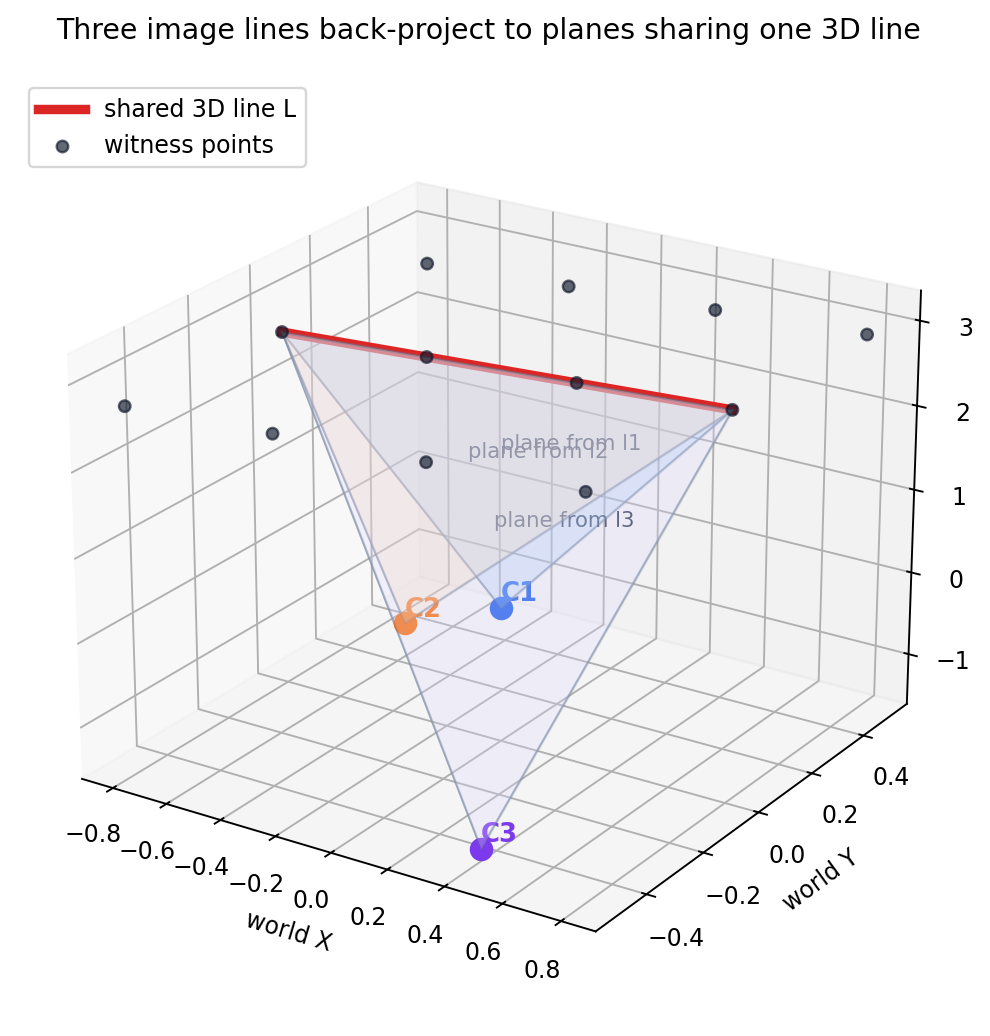

{'line_transfer_residual': 1.3447738708121478e-17}

In [4]:
line_pair = (1, 10)
A3 = points3d[line_pair[0]]
B3 = points3d[line_pair[1]]
line1 = line_through(x1[line_pair[0]], x1[line_pair[1]])
line2 = line_through(x2[line_pair[0]], x2[line_pair[1]])
line3 = line_through(x3[line_pair[0]], x3[line_pair[1]])
line1_from_tensor = line_transfer_to_view1(T, line2, line3)
line_transfer_residual = scale_invariant_line_residual(line1, line1_from_tensor)
check_values["line_transfer_residual"] = line_transfer_residual

fig = plt.figure(figsize=(9.6, 7.2))
ax = fig.add_subplot(111, projection="3d")
centers = np.vstack([C1, C2, C3])
center_colors = [COLORS["blue"], COLORS["orange"], COLORS["purple"]]
for center, color, label in zip(centers, center_colors, ["C1", "C2", "C3"]):
    ax.scatter(center[0], center[1], center[2], s=80, color=color, depthshade=False)
    ax.text(center[0], center[1], center[2] + 0.08, label, color=color, fontsize=11, weight="bold")

plane_colors = ["#93c5fd", "#fed7aa", "#ddd6fe"]
plane_labels = ["plane from l1", "plane from l2", "plane from l3"]
for center, color, label in zip(centers, plane_colors, plane_labels):
    patch = Poly3DCollection([[center, A3, B3]], alpha=0.26, facecolor=color, edgecolor="#64748b", linewidth=1.0)
    ax.add_collection3d(patch)
    mid = (center + A3 + B3) / 3.0
    ax.text(mid[0], mid[1], mid[2], label, color="#334155", fontsize=9)

ax.plot([A3[0], B3[0]], [A3[1], B3[1]], [A3[2], B3[2]], color=COLORS["red"], linewidth=4, label="shared 3D line L")
ax.scatter(points3d[:, 0], points3d[:, 1], points3d[:, 2], s=24, color="#0f172a", alpha=0.65, label="witness points")
for center in centers:
    for endpoint in [A3, B3]:
        ax.plot([center[0], endpoint[0]], [center[1], endpoint[1]], [center[2], endpoint[2]], color="#94a3b8", linewidth=0.8, alpha=0.75)

ax.set_title("Three image lines back-project to planes sharing one 3D line", pad=16)
ax.set_xlabel("world X")
ax.set_ylabel("world Y")
ax.set_zlabel("world Z")
ax.view_init(elev=23, azim=-57)
ax.legend(loc="upper left")
fig_path = save_matplotlib(fig, TOPIC, "figures", "line-triplet-backprojection-planes.png", dpi=170)
plt.close(fig)
artifact_paths.append(fig_path)
display_artifact(fig_path, width=880)

{"line_transfer_residual": line_transfer_residual}

## 2. Tensor Slices, Null-Lines, Epipoles, and Pairwise Fundamentals

Each slice is a difference of two outer products, so every `T_i` has rank at most 2. Its left null-vector is an epipolar line in the second view; its right null-vector is an epipolar line in the third view. The common intersections of those null-lines are the epipoles `e'` and `e''` produced by the first camera center.

Once those epipoles are known, the tensor gives the pairwise fundamental matrices involving the first view:

\[F_{21}=[e']_x [T_1,T_2,T_3]e'',\quad F_{31}=[e'']_x [T_1^T,T_2^T,T_3^T]e'.\]

<local-path> UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


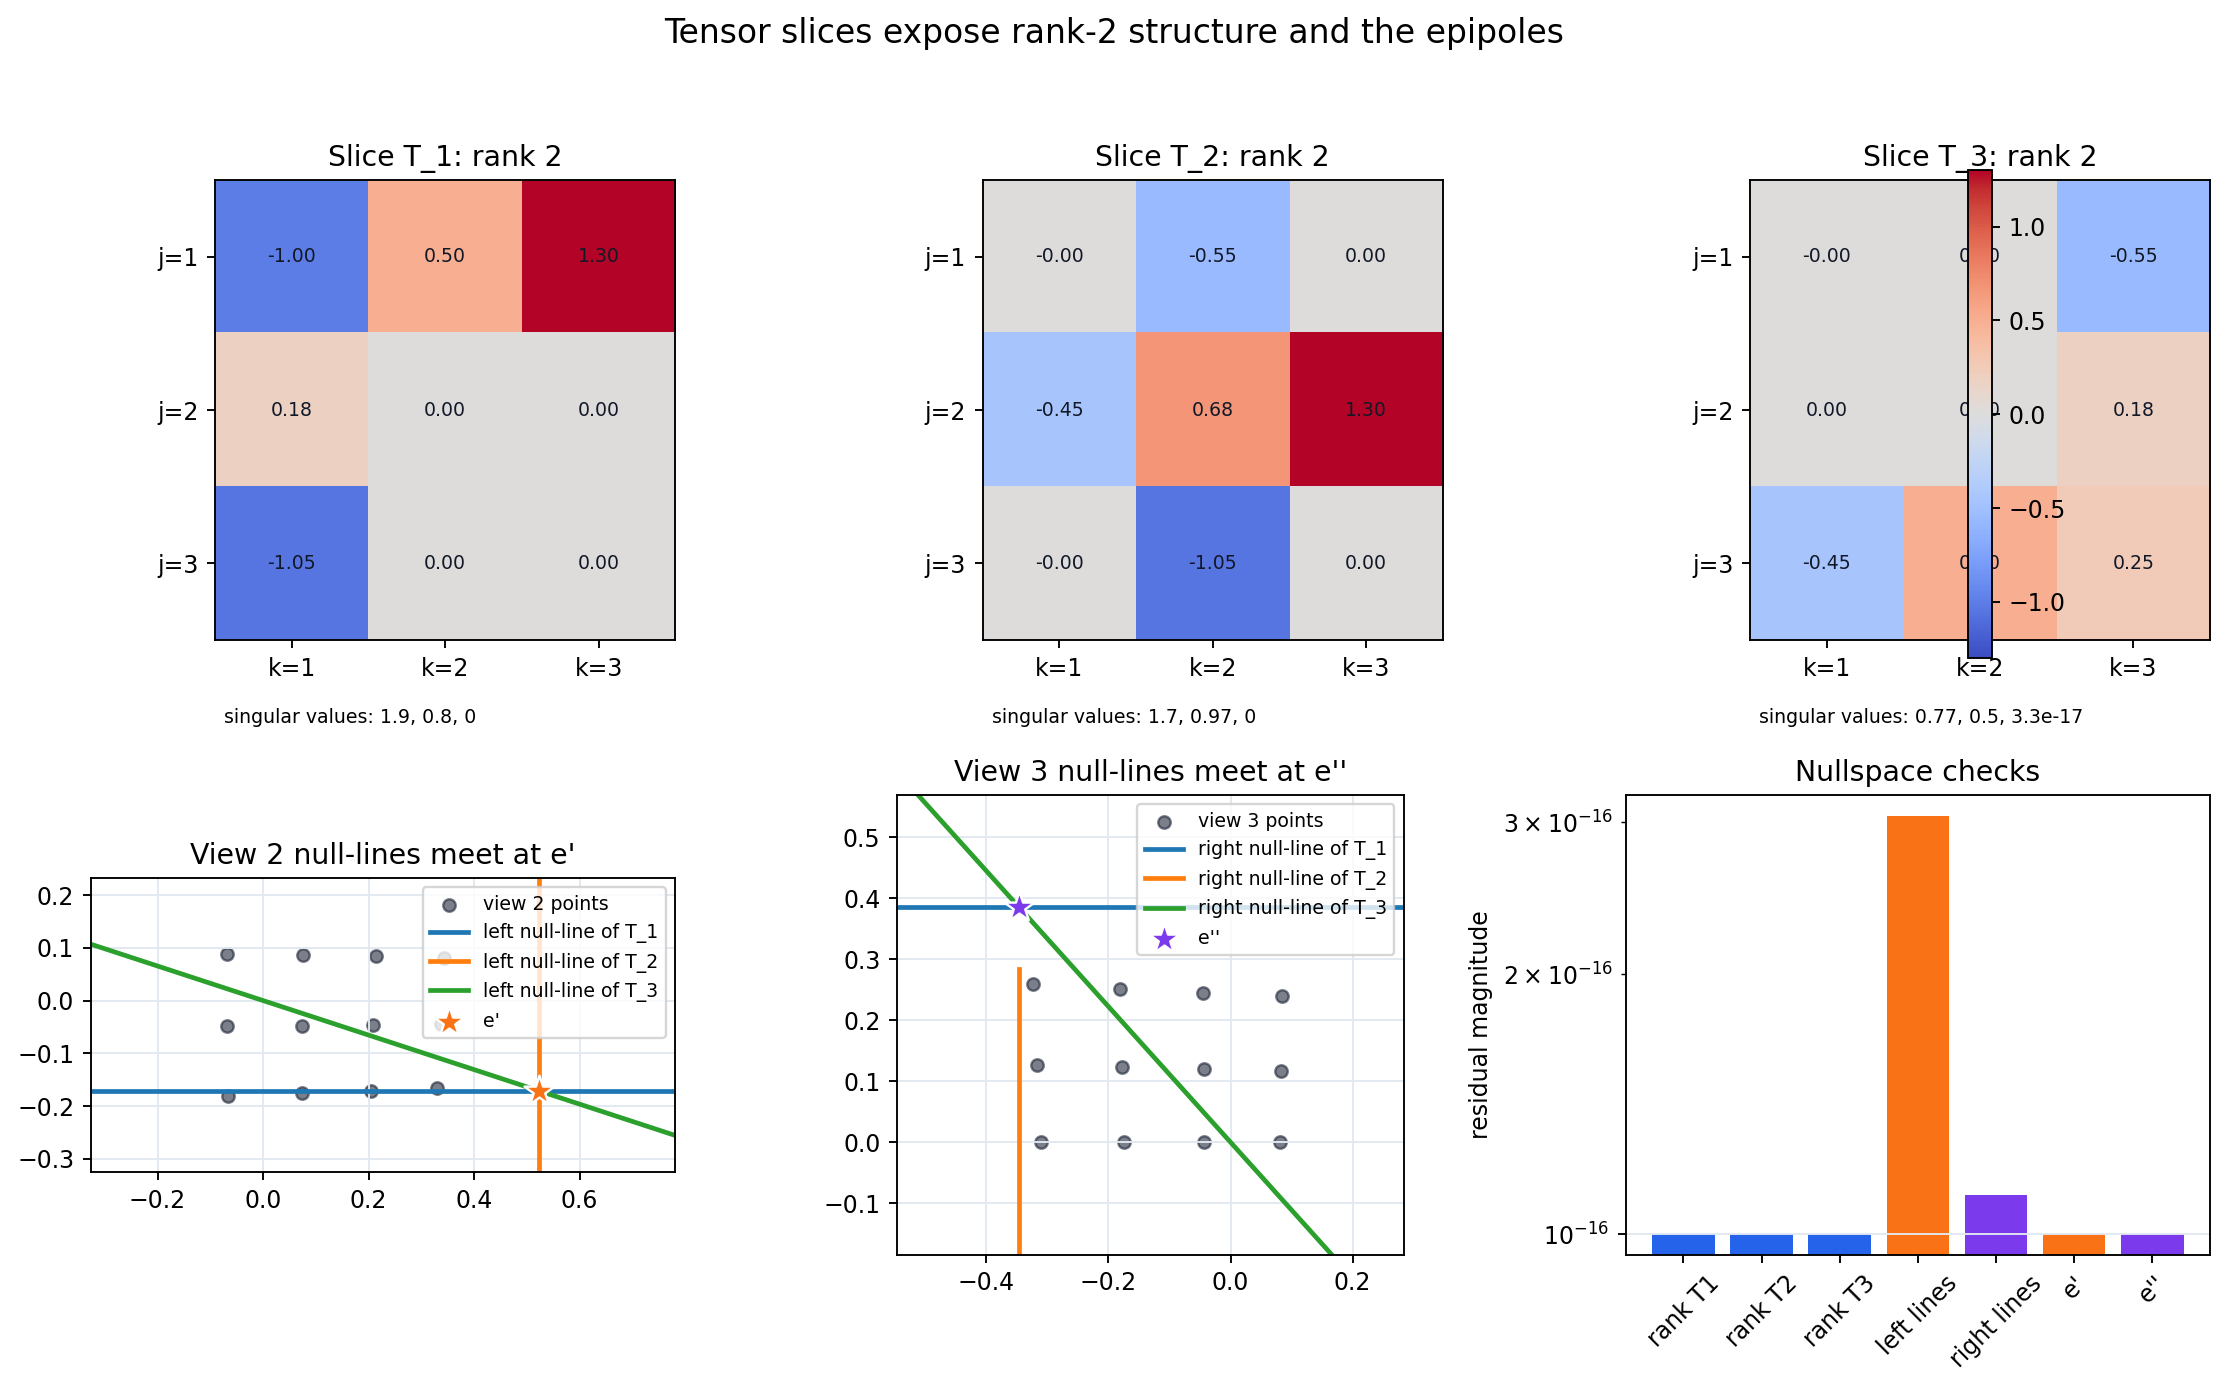

{'slice_rank_residuals': [0.0, 0.0, 4.304650446366389e-17]}

In [5]:
slice_singular_values = [np.linalg.svd(Ti, compute_uv=False) for Ti in T]
slice_rank_residuals = [matrix_rank_residual(Ti) for Ti in T]
left_null_epipole_residuals = [float(abs(left_null_lines[:, i] @ e2_from_slices)) for i in range(3)]
right_null_epipole_residuals = [float(abs(right_null_lines[:, i] @ e3_from_slices)) for i in range(3)]
check_values["max_slice_rank_residual"] = float(max(slice_rank_residuals))
check_values["max_left_null_epipole_residual"] = float(max(left_null_epipole_residuals))
check_values["max_right_null_epipole_residual"] = float(max(right_null_epipole_residuals))
check_values["e2_camera_residual"] = homogeneous_point_error(e2_from_slices, e2_camera)
check_values["e3_camera_residual"] = homogeneous_point_error(e3_from_slices, e3_camera)

view2_bounds = image_bounds(x2, extras=[e2_from_slices[:2]], pad=0.35)
view3_bounds = image_bounds(x3, extras=[e3_from_slices[:2]], pad=0.35)

fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.2))
max_abs = max(float(np.max(np.abs(Ti))) for Ti in T)
for i, ax in enumerate(axes[0]):
    im = ax.imshow(T[i], cmap="coolwarm", vmin=-max_abs, vmax=max_abs)
    ax.set_title(f"Slice T_{i+1}: rank {np.linalg.matrix_rank(T[i])}")
    for r in range(3):
        for c in range(3):
            ax.text(c, r, f"{T[i, r, c]:.2f}", ha="center", va="center", fontsize=8, color="#111827")
    ax.set_xticks(range(3), ["k=1", "k=2", "k=3"])
    ax.set_yticks(range(3), ["j=1", "j=2", "j=3"])
    ax.text(0.02, -0.18, "singular values: " + ", ".join(f"{s:.2g}" for s in slice_singular_values[i]), transform=ax.transAxes, fontsize=8)
fig.colorbar(im, ax=axes[0].tolist(), fraction=0.025, pad=0.015)

ax = axes[1, 0]
ax.scatter(x2[:, 0], x2[:, 1], s=28, color="#0f172a", alpha=0.55, label="view 2 points")
for i in range(3):
    xs, ys = line_through_image_xrange(left_null_lines[:, i], view2_bounds[:2])
    ax.plot(xs, ys, linewidth=2, label=f"left null-line of T_{i+1}")
ax.scatter([e2_from_slices[0]], [e2_from_slices[1]], marker="*", s=180, color=COLORS["orange"], edgecolor="white", zorder=5, label="e'")
ax.set_xlim(view2_bounds[0], view2_bounds[1])
ax.set_ylim(view2_bounds[2], view2_bounds[3])
ax.set_aspect("equal", adjustable="box")
ax.set_title("View 2 null-lines meet at e'")
ax.legend(fontsize=8, loc="best")
ax.grid(True, color="#e2e8f0")

ax = axes[1, 1]
ax.scatter(x3[:, 0], x3[:, 1], s=28, color="#0f172a", alpha=0.55, label="view 3 points")
for i in range(3):
    xs, ys = line_through_image_xrange(right_null_lines[:, i], view3_bounds[:2])
    ax.plot(xs, ys, linewidth=2, label=f"right null-line of T_{i+1}")
ax.scatter([e3_from_slices[0]], [e3_from_slices[1]], marker="*", s=180, color=COLORS["purple"], edgecolor="white", zorder=5, label="e''")
ax.set_xlim(view3_bounds[0], view3_bounds[1])
ax.set_ylim(view3_bounds[2], view3_bounds[3])
ax.set_aspect("equal", adjustable="box")
ax.set_title("View 3 null-lines meet at e''")
ax.legend(fontsize=8, loc="best")
ax.grid(True, color="#e2e8f0")

ax = axes[1, 2]
labels = ["rank T1", "rank T2", "rank T3", "left lines", "right lines", "e'", "e''"]
values = slice_rank_residuals + [max(left_null_epipole_residuals), max(right_null_epipole_residuals), check_values["e2_camera_residual"], check_values["e3_camera_residual"]]
ax.bar(labels, np.maximum(values, 1e-16), color=[COLORS["blue"]] * 3 + [COLORS["orange"], COLORS["purple"], COLORS["orange"], COLORS["purple"]])
ax.set_yscale("log")
ax.set_ylabel("residual magnitude")
ax.set_title("Nullspace checks")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", color="#e2e8f0")

fig.suptitle("Tensor slices expose rank-2 structure and the epipoles", y=0.99, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = save_matplotlib(fig, TOPIC, "figures", "tensor-slice-nullspaces-and-epipoles.png", dpi=170)
plt.close(fig)
artifact_paths.append(fig_path)
display_artifact(fig_path, width=900)

{"slice_rank_residuals": slice_rank_residuals}

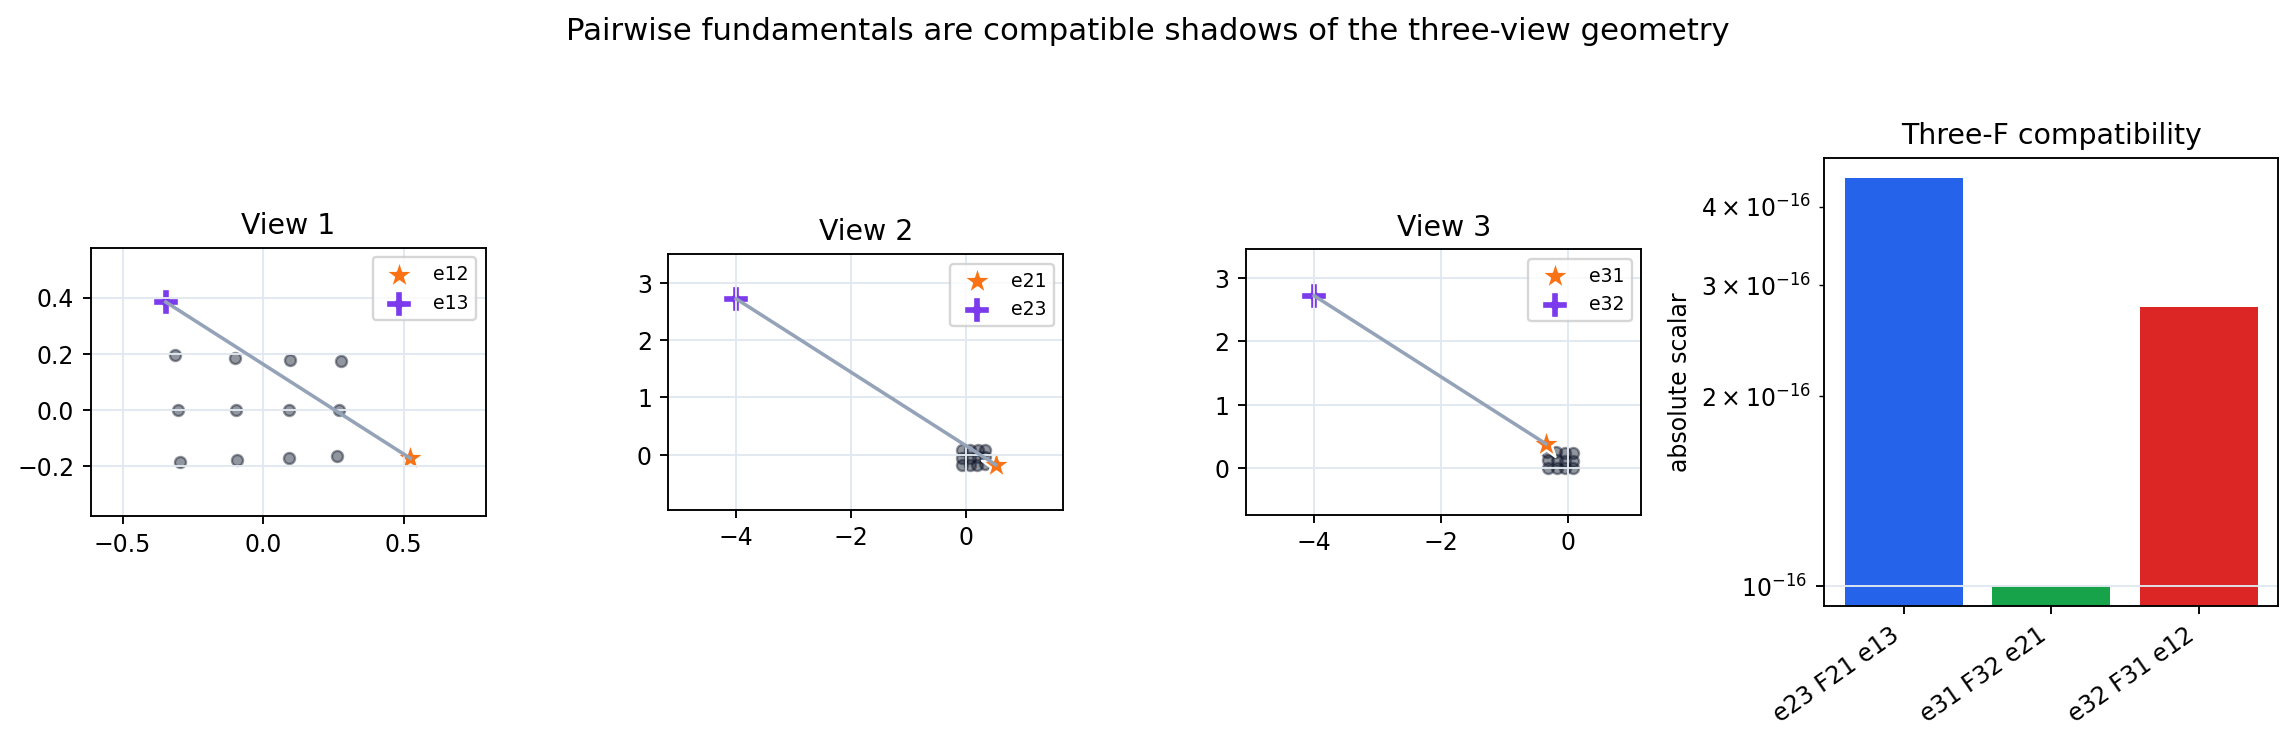

{'compatibility': {'e23T_F21_e13': 4.440892098500626e-16,
  'e31T_F32_e21': 8.326672684688674e-17,
  'e32T_F31_e12': 2.7755575615628914e-16},
 'noncollinearity': {'view1_epipole_distance': 1.0324830004077723,
  'view2_epipole_distance': 5.368911602120404,
  'view3_epipole_distance': 4.336428601712648},
 'F21_median_sampson': 1.711590106514621e-33,
 'F31_median_sampson': 2.2550930396656936e-33,
 'F32_median_sampson': 4.883260706047887e-33}

In [6]:
F21_direct = normalize_vector(fundamental_from_cameras(P1, P2))
F31_direct = normalize_vector(fundamental_from_cameras(P1, P3))
check_values["F21_tensor_vs_camera"] = float(min(np.linalg.norm(F21 - F21_direct), np.linalg.norm(F21 + F21_direct)))
check_values["F31_tensor_vs_camera"] = float(min(np.linalg.norm(F31 - F31_direct), np.linalg.norm(F31 + F31_direct)))

C1h = camera_center(P1)
C2h = camera_center(P2)
C3h = camera_center(P3)
e12 = normalize_point(P1 @ C2h)
e13 = normalize_point(P1 @ C3h)
e21 = normalize_point(P2 @ C1h)
e23 = normalize_point(P2 @ C3h)
e31 = normalize_point(P3 @ C1h)
e32 = normalize_point(P3 @ C2h)
compatibility = {
    "e23T_F21_e13": float(abs(e23 @ F21 @ e13)),
    "e31T_F32_e21": float(abs(e31 @ F32 @ e21)),
    "e32T_F31_e12": float(abs(e32 @ F31 @ e12)),
}
check_values["max_fundamental_compatibility_residual"] = float(max(compatibility.values()))
pairwise_sampson = {
    "F21_median_sampson": float(np.median(sampson_errors(F21, x1, x2))),
    "F31_median_sampson": float(np.median(sampson_errors(F31, x1, x3))),
    "F32_median_sampson": float(np.median(sampson_errors(F32, x2, x3))),
}
check_values.update(pairwise_sampson)
noncollinearity = {
    "view1_epipole_distance": float(np.linalg.norm(dehomogenize(e12) - dehomogenize(e13))),
    "view2_epipole_distance": float(np.linalg.norm(dehomogenize(e21) - dehomogenize(e23))),
    "view3_epipole_distance": float(np.linalg.norm(dehomogenize(e31) - dehomogenize(e32))),
}
check_values["min_noncollinear_epipole_distance"] = float(min(noncollinearity.values()))

fig, axes = plt.subplots(1, 4, figsize=(13.6, 4.2), gridspec_kw={"width_ratios": [1, 1, 1, 1.15]})
view_epipoles = [
    ("View 1", (e12, "e12"), (e13, "e13"), x1),
    ("View 2", (e21, "e21"), (e23, "e23"), x2),
    ("View 3", (e31, "e31"), (e32, "e32"), x3),
]
for ax, (title, item_a, item_b, pts) in zip(axes[:3], view_epipoles):
    ep_a, label_a = item_a
    ep_b, label_b = item_b
    bounds = image_bounds(pts, extras=[ep_a[:2], ep_b[:2]], pad=0.25)
    ax.scatter(pts[:, 0], pts[:, 1], s=22, color="#0f172a", alpha=0.45)
    ax.scatter([ep_a[0]], [ep_a[1]], marker="*", s=170, color=COLORS["orange"], edgecolor="white", label=label_a)
    ax.scatter([ep_b[0]], [ep_b[1]], marker="P", s=120, color=COLORS["purple"], edgecolor="white", label=label_b)
    ax.plot([ep_a[0], ep_b[0]], [ep_a[1], ep_b[1]], color="#94a3b8", linewidth=1.5)
    ax.set_xlim(bounds[0], bounds[1])
    ax.set_ylim(bounds[2], bounds[3])
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.grid(True, color="#e2e8f0")
    ax.legend(fontsize=8)

ax = axes[3]
bar_values = [max(v, 1e-16) for v in compatibility.values()]
ax.bar(range(3), bar_values, color=[COLORS["blue"], COLORS["green"], COLORS["red"]])
ax.set_xticks(range(3), ["e23 F21 e13", "e31 F32 e21", "e32 F31 e12"], rotation=35, ha="right")
ax.set_yscale("log")
ax.set_ylabel("absolute scalar")
ax.set_title("Three-F compatibility")
ax.grid(True, axis="y", color="#e2e8f0")
fig.suptitle("Pairwise fundamentals are compatible shadows of the three-view geometry", y=1.03, fontsize=13)
fig.tight_layout()
fig_path = save_matplotlib(fig, TOPIC, "figures", "fundamental-compatibility-epipoles.png", dpi=170)
plt.close(fig)
artifact_paths.append(fig_path)
display_artifact(fig_path, width=900)

{"compatibility": compatibility, "noncollinearity": noncollinearity, **pairwise_sampson}

## 3. Plane-Induced Homographies and Point Transfer

A line in view 2 back-projects to a plane through the second camera center. That plane induces a homography from view 1 to view 3. This is the transfer mechanism behind the tensor contraction `H13(l2)`.

The interactive artifact chooses a line in view 2 by projecting two scene points and taking their image line. The resulting plane contains those two scene points and the second camera center. For points on that plane, applying `H13(l2)` to their view-1 coordinates lands on their actual view-3 coordinates.

In [7]:
plane_indices = (2, 8)
Q0 = points3d[plane_indices[0]]
Q1 = points3d[plane_indices[1]]
Q2 = Q0 + 0.45 * (Q1 - Q0) + 0.35 * (C2 - Q0)
Q3 = Q1 + 0.30 * (Q0 - Q1) + 0.42 * (C2 - Q1)
plane_points = np.vstack([Q0, Q1, Q2, Q3])
plane_x1 = project(P1, plane_points)
plane_x2 = project(P2, plane_points)
plane_x3 = project(P3, plane_points)
plane_line2 = line_through(plane_x2[0], plane_x2[1])
H13 = contract_H13(T, plane_line2)
plane_x3_from_H = normalize_point((H13 @ plane_x1.T).T)
plane_homography_errors = np.linalg.norm(dehomogenize(plane_x3_from_H) - dehomogenize(plane_x3), axis=1)
check_values["plane_homography_max_error"] = float(np.max(plane_homography_errors))

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "xy"}]],
    column_widths=[0.58, 0.42],
    subplot_titles=("Back-projected plane selected by a view-2 line", "View 3: true vs H13(l') transfer"),
)
fig.add_trace(go.Mesh3d(x=plane_points[:, 0], y=plane_points[:, 1], z=plane_points[:, 2], i=[0, 0], j=[1, 2], k=[2, 3], opacity=0.28, color="#93c5fd", name="plane from l'"), row=1, col=1)
fig.add_trace(go.Scatter3d(x=plane_points[:, 0], y=plane_points[:, 1], z=plane_points[:, 2], mode="markers+text", text=["Q0", "Q1", "Q2", "Q3"], textposition="top center", marker=dict(size=5, color="#0f172a"), name="plane points"), row=1, col=1)
fig.add_trace(go.Scatter3d(x=[C1[0], C2[0], C3[0]], y=[C1[1], C2[1], C3[1]], z=[C1[2], C2[2], C3[2]], mode="markers+text", text=["C1", "C2", "C3"], textposition="bottom center", marker=dict(size=6, color=[COLORS["blue"], COLORS["orange"], COLORS["purple"]]), name="camera centers"), row=1, col=1)
for point in [Q0, Q1]:
    fig.add_trace(go.Scatter3d(x=[C2[0], point[0]], y=[C2[1], point[1]], z=[C2[2], point[2]], mode="lines", line=dict(color="#f97316", width=4), showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=plane_x3[:, 0], y=plane_x3[:, 1], mode="markers+text", text=["true Q0", "true Q1", "true Q2", "true Q3"], textposition="top center", marker=dict(size=10, color=COLORS["purple"]), name="true view 3"), row=1, col=2)
fig.add_trace(go.Scatter(x=plane_x3_from_H[:, 0], y=plane_x3_from_H[:, 1], mode="markers", marker=dict(size=13, symbol="circle-open", color=COLORS["orange"], line=dict(width=2)), name="H13(l') transfer"), row=1, col=2)
for true_pt, transferred_pt in zip(plane_x3, plane_x3_from_H):
    fig.add_trace(go.Scatter(x=[true_pt[0], transferred_pt[0]], y=[true_pt[1], transferred_pt[1]], mode="lines", line=dict(color="#94a3b8", width=1), showlegend=False), row=1, col=2)
fig.update_xaxes(scaleanchor="y", scaleratio=1, row=1, col=2, title_text="x''")
fig.update_yaxes(row=1, col=2, title_text="y''")
fig.update_layout(title="A contracted trifocal tensor is a plane-induced homography", height=620, width=1040, template="plotly_white")
fig.update_scenes(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data")
html_path = save_plotly_html(fig, TOPIC, "interactive", "plane-induced-homography-family.html")
artifact_paths.append(html_path)
display_artifact(html_path, width=920, height=560)

{"plane_line2": normalize_vector(plane_line2).tolist(), "plane_homography_errors": plane_homography_errors.tolist()}

.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'plane_line2': [0.01739366713610733,
  0.9960592195911426,
  -0.08696833568053633],
 'plane_homography_errors': [5.551115123125783e-17,
  2.7755575615628914e-17,
  7.850462293418876e-17,
  0.0]}

## 4. Point Transfer: Tensor Transfer Versus Epipolar Transfer

Pairwise epipolar transfer intersects two lines in the third image: `F31 x` and `F32 x'`. It fails when those two lines coincide, and becomes noisy when they are nearly parallel. The geometric cause is the trifocal plane through the three camera centers.

Tensor transfer uses a line through `x'` in the second view to select a plane and then transfers `x` through the induced homography. It is still undefined for the baseline between the first two cameras, but it does not collapse merely because the point lies on the trifocal plane.

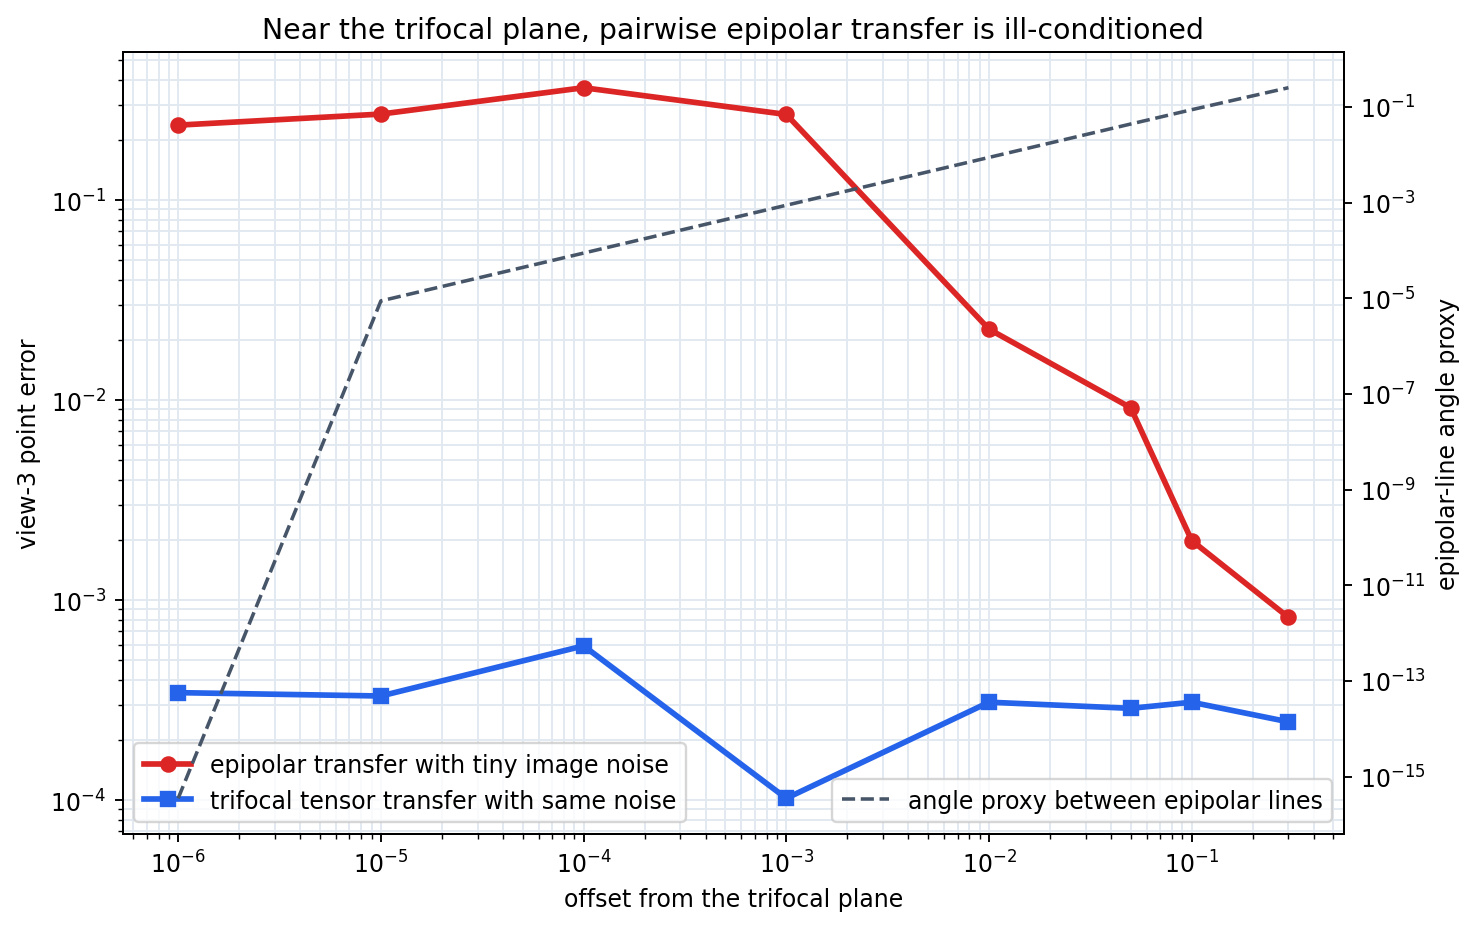

[point-transfer-stability-near-trifocal-plane.csv](Multiple-View-Geometry-in-Computer-Vision/artifacts/chapter-15/tables/point-transfer-stability-near-trifocal-plane.csv)

[{'offset_from_trifocal_plane': 0.0,
  'epipolar_line_angle_proxy': 3.5135752366389115e-16,
  'epipolar_transfer_error': 0.23705677383189677,
  'tensor_transfer_error': 0.0003452876911417776},
 {'offset_from_trifocal_plane': 1e-05,
  'epipolar_line_angle_proxy': 8.803684093086988e-06,
  'epipolar_transfer_error': 0.26920328297385454,
  'tensor_transfer_error': 0.00033223496640330676},
 {'offset_from_trifocal_plane': 0.0001,
  'epipolar_line_angle_proxy': 8.80368404676155e-05,
  'epipolar_transfer_error': 0.36467074090244317,
  'tensor_transfer_error': 0.000591719315065757},
 {'offset_from_trifocal_plane': 0.001,
  'epipolar_line_angle_proxy': 0.0008803679377420336,
  'epipolar_transfer_error': 0.26804381401879496,
  'tensor_transfer_error': 0.00010234978804943587},
 {'offset_from_trifocal_plane': 0.01,
  'epipolar_line_angle_proxy': 0.00880321247547676,
  'epipolar_transfer_error': 0.022646458641698747,
  'tensor_transfer_error': 0.00030934188574600105},
 {'offset_from_trifocal_plane':

In [8]:
trifocal_plane_normal = normalize_vector(np.cross(C2 - C1, C3 - C1))
base_on_trifocal_plane = -C2 - C3
rng = np.random.default_rng(15)
noise_sigma = 2e-4
offsets = np.array([0.0, 1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 3e-1])
transfer_rows = []
for offset in offsets:
    X = base_on_trifocal_plane + offset * trifocal_plane_normal
    hX = np.r_[X, 1.0]
    px1 = normalize_point(P1 @ hX)
    px2 = normalize_point(P2 @ hX)
    px3 = normalize_point(P3 @ hX)
    px1_noisy = normalize_point(px1 + np.r_[rng.normal(0.0, noise_sigma, 2), 0.0])
    px2_noisy = normalize_point(px2 + np.r_[rng.normal(0.0, noise_sigma, 2), 0.0])

    epipolar_candidate = normalize_point(np.cross(F31 @ px1_noisy, F32 @ px2_noisy))
    line_e = F21 @ px1_noisy
    u, v, _ = px2_noisy
    transfer_line2 = np.array([line_e[1], -line_e[0], -u * line_e[1] + v * line_e[0]])
    tensor_candidate = normalize_point(point_transfer_to_view3(T, px1_noisy, transfer_line2))

    exact_line_angle = np.linalg.norm(np.cross(normalize_vector(F31 @ px1), normalize_vector(F32 @ px2)))
    transfer_rows.append({
        "offset_from_trifocal_plane": float(offset),
        "epipolar_line_angle_proxy": float(exact_line_angle),
        "epipolar_transfer_error": homogeneous_point_error(epipolar_candidate, px3),
        "tensor_transfer_error": homogeneous_point_error(tensor_candidate, px3),
    })

check_values["max_tensor_transfer_noise_error"] = float(max(row["tensor_transfer_error"] for row in transfer_rows))
check_values["max_epipolar_transfer_near_plane_error"] = float(max(row["epipolar_transfer_error"] for row in transfer_rows[:4]))
check_values["min_epipolar_line_angle_proxy"] = float(min(row["epipolar_line_angle_proxy"] for row in transfer_rows))

csv_path = save_csv(transfer_rows, TOPIC, "tables", "point-transfer-stability-near-trifocal-plane.csv")
artifact_paths.append(csv_path)

fig, ax = plt.subplots(figsize=(8.8, 5.6))
plot_offsets = np.maximum(offsets, 1e-6)
epi_errors = np.array([row["epipolar_transfer_error"] for row in transfer_rows])
tensor_errors = np.array([row["tensor_transfer_error"] for row in transfer_rows])
line_angles = np.array([max(row["epipolar_line_angle_proxy"], 1e-16) for row in transfer_rows])
ax.loglog(plot_offsets, epi_errors, marker="o", linewidth=2.4, color=COLORS["red"], label="epipolar transfer with tiny image noise")
ax.loglog(plot_offsets, tensor_errors, marker="s", linewidth=2.4, color=COLORS["blue"], label="trifocal tensor transfer with same noise")
ax.set_xlabel("offset from the trifocal plane")
ax.set_ylabel("view-3 point error")
ax.grid(True, which="both", color="#e2e8f0")
ax.legend(loc="best")
ax2 = ax.twinx()
ax2.loglog(plot_offsets, line_angles, linestyle="--", color=COLORS["gray"], label="angle proxy between epipolar lines")
ax2.set_ylabel("epipolar-line angle proxy")
ax2.legend(loc="lower right")
ax.set_title("Near the trifocal plane, pairwise epipolar transfer is ill-conditioned")
fig.tight_layout()
fig_path = save_matplotlib(fig, TOPIC, "figures", "point-transfer-stability-near-trifocal-plane.png", dpi=170)
plt.close(fig)
artifact_paths.append(fig_path)
display_artifact(fig_path, width=860)
display_artifact(csv_path)

transfer_rows

## 5. Line Choice in Tensor Point Transfer

For an exact pair `x <-> x'`, any non-epipolar line through `x'` gives the same transferred point in the third view. The epipolar line is the forbidden choice: contracting with that line sends the transfer vector toward zero, so the homogeneous point is undefined.

This small lab is the practical version of the chapter's warning. It compares several lines through the same second-view point and shows the candidate in the third image.

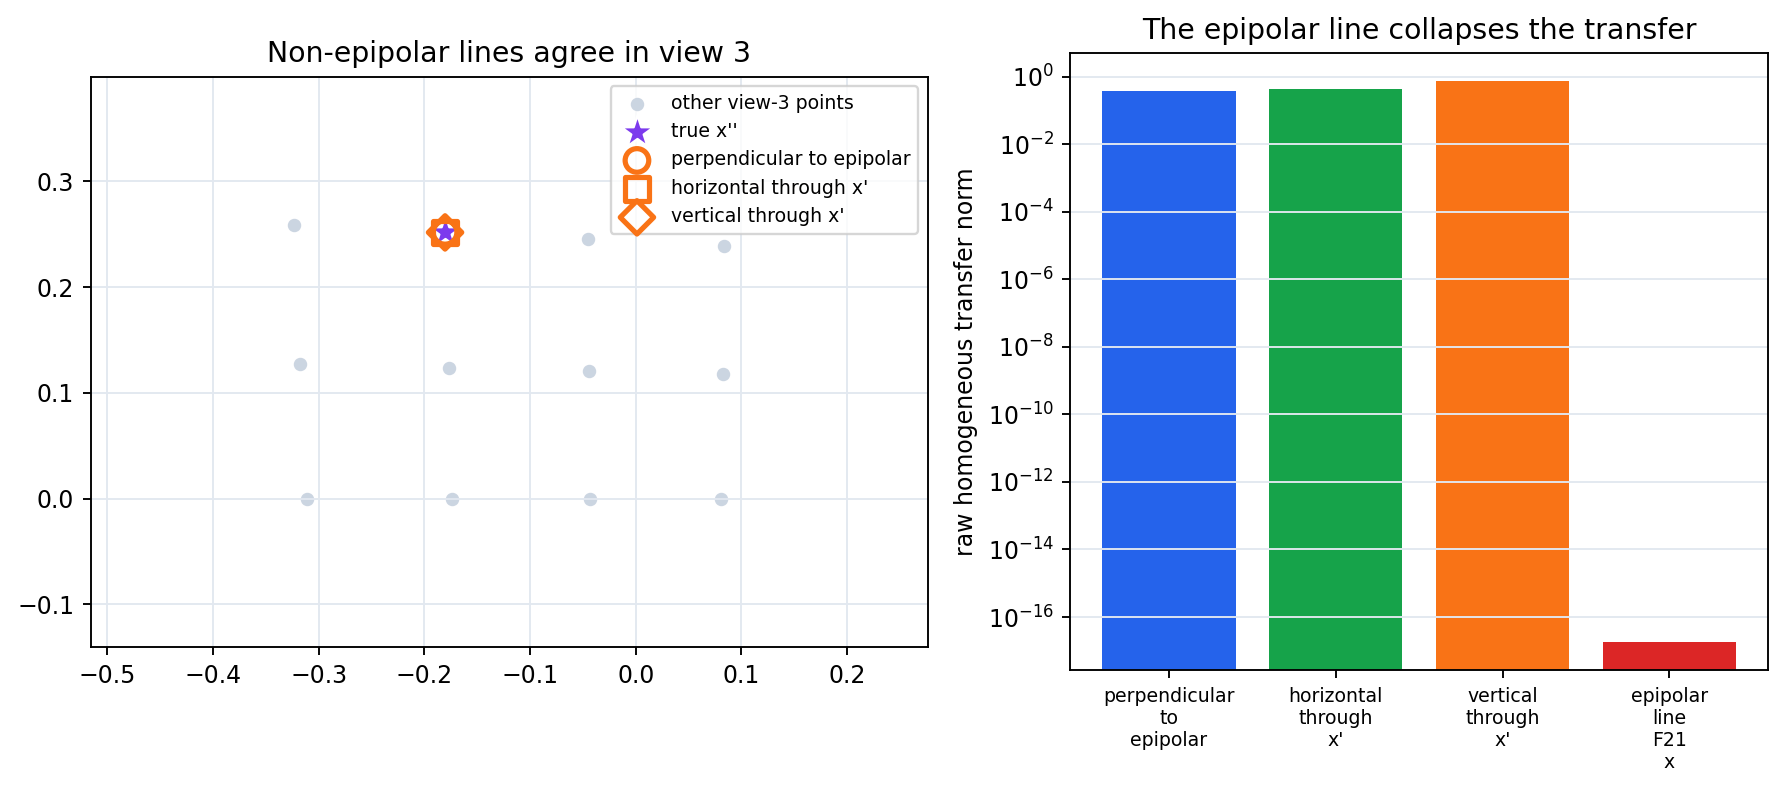

[{'line': 'perpendicular to epipolar',
  'raw_norm': 0.37592606306023396,
  'transfer_error': 6.206335383118183e-17,
  'x3_x': -0.18044481745698698,
  'x3_y': 0.25178346621905157},
 {'line': "horizontal through x'",
  'raw_norm': 0.420633894834527,
  'transfer_error': 2.7755575615628914e-17,
  'x3_x': -0.18044481745698698,
  'x3_y': 0.2517834662190516},
 {'line': "vertical through x'",
  'raw_norm': 0.731547814085332,
  'transfer_error': 0.0,
  'x3_x': -0.180444817456987,
  'x3_y': 0.2517834662190516},
 {'line': 'epipolar line F21 x',
  'raw_norm': 1.7690777709386487e-17,
  'transfer_error': None,
  'x3_x': None,
  'x3_y': None}]

In [9]:
sample_index = 5
sample_x1 = x1[sample_index]
sample_x2 = x2[sample_index]
sample_x3 = x3[sample_index]
le = F21 @ sample_x1
u, v, _ = sample_x2
candidate_lines = {
    "perpendicular to epipolar": np.array([le[1], -le[0], -u * le[1] + v * le[0]]),
    "horizontal through x'": np.array([0.0, 1.0, -v]),
    "vertical through x'": np.array([1.0, 0.0, -u]),
    "epipolar line F21 x": le,
}
line_choice_rows = []
for name, line in candidate_lines.items():
    raw = point_transfer_to_view3(T, sample_x1, line)
    raw_norm = float(np.linalg.norm(raw))
    if raw_norm > 1e-10:
        candidate = normalize_point(raw)
        error = homogeneous_point_error(candidate, sample_x3)
        xy = dehomogenize(candidate)
    else:
        error = None
        xy = np.array([np.nan, np.nan])
    line_choice_rows.append({
        "line": name,
        "raw_norm": raw_norm,
        "transfer_error": None if error is None else float(error),
        "x3_x": None if not np.isfinite(xy[0]) else float(xy[0]),
        "x3_y": None if not np.isfinite(xy[1]) else float(xy[1]),
    })

valid_line_errors = [row["transfer_error"] for row in line_choice_rows if row["transfer_error"] is not None]
epipolar_line_norm = next(row["raw_norm"] for row in line_choice_rows if row["line"] == "epipolar line F21 x")
check_values["max_valid_line_choice_transfer_error"] = float(max(valid_line_errors))
check_values["epipolar_line_transfer_norm"] = float(epipolar_line_norm)

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.7), gridspec_kw={"width_ratios": [1.2, 1.0]})
ax = axes[0]
bounds = image_bounds(x3, extras=[sample_x3[:2]], pad=0.35)
ax.scatter(x3[:, 0], x3[:, 1], s=22, color="#cbd5e1", label="other view-3 points")
ax.scatter([sample_x3[0]], [sample_x3[1]], marker="*", s=210, color=COLORS["purple"], edgecolor="white", label="true x''")
markers = ["o", "s", "D"]
for marker, row in zip(markers, [r for r in line_choice_rows if r["transfer_error"] is not None]):
    ax.scatter([row["x3_x"]], [row["x3_y"]], s=100, marker=marker, facecolor="none", edgecolor=COLORS["orange"], linewidth=2.2, label=row["line"])
ax.set_xlim(bounds[0], bounds[1])
ax.set_ylim(bounds[2], bounds[3])
ax.set_aspect("equal", adjustable="box")
ax.grid(True, color="#e2e8f0")
ax.set_title("Non-epipolar lines agree in view 3")
ax.legend(fontsize=8)

ax = axes[1]
labels = [row["line"].replace(" ", "/n") for row in line_choice_rows]
norms = [max(row["raw_norm"], 1e-18) for row in line_choice_rows]
ax.bar(range(len(norms)), norms, color=[COLORS["blue"], COLORS["green"], COLORS["orange"], COLORS["red"]])
ax.set_yscale("log")
ax.set_xticks(range(len(norms)), labels, fontsize=8)
ax.set_ylabel("raw homogeneous transfer norm")
ax.set_title("The epipolar line collapses the transfer")
ax.grid(True, axis="y", color="#e2e8f0")
fig.tight_layout()
fig_path = save_matplotlib(fig, TOPIC, "figures", "line-choice-transfer-candidates.png", dpi=170)
plt.close(fig)
artifact_paths.append(fig_path)
display_artifact(fig_path, width=880)

line_choice_rows

## 6. Trilinear Constraints as Executable Tensor Notation

Tensor notation pays off when a relation mixes points and lines across all three views. The point-point-point relation can be written as

\[[x']_x \left(\sum_i x_i T_i\right)[x'']_x=0.\]

The next cell evaluates the nine entries for an exact point triple and for the same triple after perturbing the third image point. The exact residuals sit at floating-point roundoff; the perturbed point breaks the trilinearity in a visible pattern.

The static diagnostic `figures/trilinear-constraint-residuals.png` makes that contrast explicit: the exact point triple has only roundoff-scale entries, while perturbing one view leaves a structured residual signature.

<local-path> UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


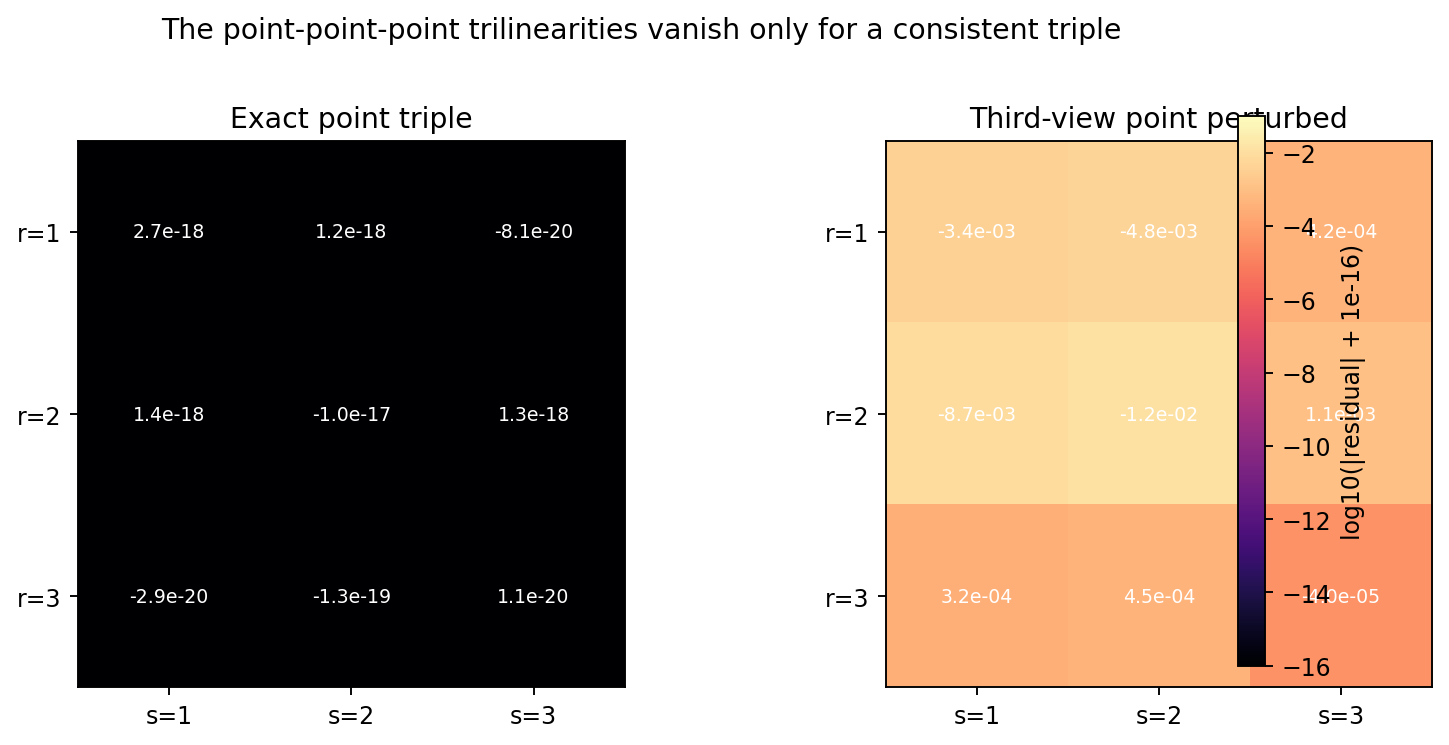

{'max_exact_trilinear': 1.0453411825072805e-17,
 'max_perturbed_trilinear': 0.012020259862566555,
 'symbolic_det': '0'}

In [10]:
tri_index = 7
exact_trilinear = trilinear_matrix(T, x1[tri_index], x2[tri_index], x3[tri_index])
perturbed_x3 = normalize_point(x3[tri_index] + np.array([0.025, -0.018, 0.0]))
perturbed_trilinear = trilinear_matrix(T, x1[tri_index], x2[tri_index], perturbed_x3)
max_exact_trilinear = float(np.max(np.abs(exact_trilinear)))
max_perturbed_trilinear = float(np.max(np.abs(perturbed_trilinear)))
check_values["max_exact_trilinear_residual"] = max_exact_trilinear
check_values["max_perturbed_trilinear_residual"] = max_perturbed_trilinear

u_symbols = sp.symbols("u0:3")
v_symbols = sp.symbols("v0:3")
p_symbols = sp.symbols("p0:3")
q_symbols = sp.symbols("q0:3")
rank_two_template = sp.Matrix(u_symbols) * sp.Matrix(v_symbols).T - sp.Matrix(p_symbols) * sp.Matrix(q_symbols).T
symbolic_slice_det = sp.factor(rank_two_template.det())
check_values["symbolic_outer_difference_det_zero"] = bool(symbolic_slice_det == 0)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
for ax, matrix, title in zip(axes, [exact_trilinear, perturbed_trilinear], ["Exact point triple", "Third-view point perturbed"]):
    log_matrix = np.log10(np.abs(matrix) + 1e-16)
    im = ax.imshow(log_matrix, cmap="magma", vmin=-16, vmax=max(-1, float(np.max(log_matrix))))
    ax.set_title(title)
    ax.set_xticks(range(3), ["s=1", "s=2", "s=3"])
    ax.set_yticks(range(3), ["r=1", "r=2", "r=3"])
    for r in range(3):
        for c in range(3):
            ax.text(c, r, f"{matrix[r, c]:.1e}", ha="center", va="center", fontsize=8, color="white")
fig.colorbar(im, ax=axes.tolist(), fraction=0.045, pad=0.03, label="log10(|residual| + 1e-16)")
fig.suptitle("The point-point-point trilinearities vanish only for a consistent triple", y=1.02)
fig.tight_layout()
fig_path = save_matplotlib(fig, TOPIC, "figures", "trilinear-constraint-residuals.png", dpi=170)
plt.close(fig)
artifact_paths.append(fig_path)
display_artifact(fig_path, width=850)

{"max_exact_trilinear": max_exact_trilinear, "max_perturbed_trilinear": max_perturbed_trilinear, "symbolic_det": str(symbolic_slice_det)}

## 7. Projective Invariance Sanity Scaffold

The source notes that the tensor is an image-coordinate object: changing the 3D projective frame should not change the three-view relation. A useful small check is to apply a 4D projective transform that preserves the first camera `P=[I|0]`:

\[H=\begin{bmatrix}I&0\\ v^T&k\end{bmatrix}.\]

Then `P H` is still `[I|0]`, and recomputing the tensor from `P' H` and `P'' H` should recover the same homogeneous tensor up to common scale.

In [11]:
v_frame = np.array([0.12, -0.07, 0.04])
k_frame = 1.35
H_frame = np.eye(4)
H_frame[3, :3] = v_frame
H_frame[3, 3] = k_frame
T_frame = trifocal_from_canonical_cameras(P2 @ H_frame, P3 @ H_frame)
T_frame_scaled = T_frame / np.linalg.norm(T_frame)
T_scaled = T / np.linalg.norm(T)
projective_invariance_residual = float(min(np.linalg.norm(T_frame_scaled - T_scaled), np.linalg.norm(T_frame_scaled + T_scaled)))
check_values["projective_frame_invariance_residual"] = projective_invariance_residual

{
    "raw_tensor_entries": 27,
    "homogeneous_ratios": 26,
    "three_camera_projective_dof": 3 * 11 - 15,
    "independent_tensor_constraints": 26 - (3 * 11 - 15),
    "projective_frame_invariance_residual": projective_invariance_residual,
}

{'raw_tensor_entries': 27,
 'homogeneous_ratios': 26,
 'three_camera_projective_dof': 18,
 'independent_tensor_constraints': 8,
 'projective_frame_invariance_residual': 1.306172968964969e-16}

## Applied Lab

Use this notebook as a template for a small three-view track experiment:

1. Replace `P2`, `P3`, and `points3d` with your own calibrated or projective synthetic camera triplet.
2. Recompute `T` from the canonical cameras, or from a tensor estimated in Chapter 16.
3. Plot the slice null-lines and check whether they still meet in stable epipoles.
4. Compare epipolar point transfer and tensor point transfer for points near the trifocal plane.
5. Treat any residual larger than the tolerances below as a geometry problem first, not as a plotting issue.

The important habit is to keep a witness for every claim: a visual, a line or point residual, and an artifact file that can be regenerated.

## Final Sanity Checks

The final cell asserts the chapter invariants and saves a machine-readable summary under the chapter artifact subtree. These checks are intentionally geometric: rank, nullspace incidence, trilinearity, transfer, compatibility, projective-frame invariance, and artifact integrity.

In [12]:
summary = {
    "source_span": "printed pages 365-390; PDF pages 383-408",
    "artifact_count_before_summary": len(artifact_paths),
    "artifacts": [str(path.relative_to(BOOK_ROOT)).replace("//", "/") for path in artifact_paths],
    "checks": check_values,
    "transfer_rows": transfer_rows,
    "line_choice_rows": line_choice_rows,
    "compatibility": compatibility,
    "noncollinearity": noncollinearity,
}
final_sanity = summary
summary_path = save_json(summary, TOPIC, "checks", "trifocal-tensor-consistency.json")
artifact_paths.append(summary_path)
summary["artifact_count"] = len(artifact_paths)
summary["artifacts"] = [str(path.relative_to(BOOK_ROOT)).replace("//", "/") for path in artifact_paths]
save_json(summary, TOPIC, "checks", "trifocal-tensor-consistency.json")

display_artifact(summary_path)

assert_artifacts(artifact_paths, min_bytes=64)
assert check_values["line_transfer_residual"] < 1e-10
assert check_values["max_slice_rank_residual"] < 1e-12
assert check_values["max_left_null_epipole_residual"] < 1e-12
assert check_values["max_right_null_epipole_residual"] < 1e-12
assert check_values["e2_camera_residual"] < 1e-12
assert check_values["e3_camera_residual"] < 1e-12
assert check_values["F21_tensor_vs_camera"] < 1e-10
assert check_values["F31_tensor_vs_camera"] < 1e-10
assert check_values["max_fundamental_compatibility_residual"] < 1e-10
assert check_values["F21_median_sampson"] < 1e-12
assert check_values["F31_median_sampson"] < 1e-12
assert check_values["F32_median_sampson"] < 1e-12
assert check_values["plane_homography_max_error"] < 1e-10
assert check_values["max_valid_line_choice_transfer_error"] < 1e-10
assert check_values["epipolar_line_transfer_norm"] < 1e-10
assert check_values["max_exact_trilinear_residual"] < 1e-12
assert check_values["max_perturbed_trilinear_residual"] > 1e-4
assert check_values["symbolic_outer_difference_det_zero"] is True
assert check_values["projective_frame_invariance_residual"] < 1e-12
assert check_values["min_noncollinear_epipole_distance"] > 0.05
assert len(artifact_paths) >= 7

summary

`artifacts/chapter-15/checks/trifocal-tensor-consistency.json`

{'source_span': 'printed pages 365-390; PDF pages 383-408',
 'artifact_count_before_summary': 8,
 'artifacts': ['artifacts/chapter-15/figures/line-triplet-backprojection-planes.png',
  'artifacts/chapter-15/figures/tensor-slice-nullspaces-and-epipoles.png',
  'artifacts/chapter-15/figures/fundamental-compatibility-epipoles.png',
  'artifacts/chapter-15/interactive/plane-induced-homography-family.html',
  'artifacts/chapter-15/tables/point-transfer-stability-near-trifocal-plane.csv',
  'artifacts/chapter-15/figures/point-transfer-stability-near-trifocal-plane.png',
  'artifacts/chapter-15/figures/line-choice-transfer-candidates.png',
  'artifacts/chapter-15/figures/trilinear-constraint-residuals.png',
  'artifacts/chapter-15/checks/trifocal-tensor-consistency.json'],
 'checks': {'line_transfer_residual': 1.3447738708121478e-17,
  'max_slice_rank_residual': 4.304650446366389e-17,
  'max_left_null_epipole_residual': 3.0531133177191805e-16,
  'max_right_null_epipole_residual': 1.1102230246

## Takeaways

- The trifocal tensor is not just a `3 x 3 x 3` array. Its three slices are rank-2 maps whose null-lines expose the epipoles of the first camera in the other two views.
- Contracting the tensor with a line turns the tensor into a plane-induced homography. That is the geometric reason point transfer can be more stable than intersecting two epipolar lines.
- The trilinearities are executable incidence tests. They vanish for consistent triples and react immediately when one view is perturbed.
- Pairwise fundamental matrices are shadows of the three-view geometry. Compatibility and non-collinearity are essential when trying to recover a camera triple from pairwise data alone.
- The tensor is homogeneous and projectively invariant: scale and 3D frame choices must not be mistaken for geometry.